## preprocessing

In [1]:
import pandas as pd
import numpy as np

In [54]:
train_df = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\processed\train_df.csv")
# testing on the 21st month - sep 2024
test_df = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\processed\test21_df.csv")

In [25]:
len(train_df.columns), len(test_df.columns)

(36, 37)

In [3]:
train_df['snapshot_date'].min(), train_df['snapshot_date'].max()

('2023-02-01', '2024-08-01')

In [4]:
test_df['snapshot_date'].min(), test_df['snapshot_date'].max()

('2024-09-01', '2024-09-01')

In [4]:
train_df.isna().sum()[train_df.isna().sum() > 0]

Series([], dtype: int64)

In [ ]:
# # temporary fix for NaNs in pro_ratio column
# columns_to_fill = ['pro_ratio', 'enterprise_ratio', 'monthly_ratio', 'active_trials']
# train_df[columns_to_fill] = train_df[columns_to_fill].fillna(0)

In [78]:
# making sure the train set is sorted for TimeSeriesSplit (Time Series Cross Validation)
train_df = train_df.sort_values('snapshot_date').reset_index(drop=True)
train_df

,account_id,snapshot_date,industry,country,referral_source,tenure_days,total_active_subs,total_mrr,total_seats,max_seats,...,total_usage_count_30d,avg_duration_last_30d,had_error_last_30d,tickets_last_30d,tickets_31_to_90d,escalated_last_90d,had_urgent_ticket_last_90d,avg_resolution_last_90d,latest_csat_score,target
0,A-10b8f2,2023-02-01,HealthTech,DE,organic,21,0,0,0,0,...,42,1656.0,0,0,0,0,0,0.0,0.0,0
1,A-91e948,2023-02-01,EdTech,AU,partner,3,0,0,0,0,...,11,1738.0,0,0,0,0,0,0.0,0.0,0
2,A-432483,2023-02-01,Cybersecurity,US,ads,0,0,0,0,0,...,13,1534.0,1,0,0,0,0,0.0,0.0,0
3,A-7df7a7,2023-02-01,DevTools,US,organic,4,0,0,0,0,...,48,3738.0,0,0,0,0,0,0.0,0.0,0
4,A-779e4e,2023-02-01,HealthTech,US,organic,30,2,3753,27,18,...,49,2762.4,1,1,0,0,1,33.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3810,A-fdfc91,2024-08-01,Cybersecurity,US,ads,453,7,5916,203,29,...,8,2736.0,0,0,0,0,0,0.0,4.0,0
3811,A-fe79a5,2024-08-01,HealthTech,IN,ads,162,5,3582,55,19,...,9,4455.0,0,0,0,0,0,0.0,5.0,0
3812,A-ff3c73,2024-08-01,HealthTech,AU,other,553,6,2682,175,66,...,19,4337.0,0,0,0,0,0,0.0,3.0,0
3813,A-e2cd1b,2024-08-01,DevTools,US,other,179,5,6761,134,45,...,24,3529.5,0,1,0,0,1,27.0,5.0,0


for the TSCV we need to drop the 'target' i.e. 'churn_flag'

In [79]:
X_train = train_df.drop(columns=['account_id', 'snapshot_date', 'target'])
y_train = train_df['target']

X_test = test_df.drop(columns=['account_id', 'snapshot_date', 'target'])
y_test = test_df['target']

In [27]:
len(X_train.columns)

33

- Categorical variables -> one‑hot encoded dummy columns.
- Train/test alignment -> same feature set across both.
- Boolean variables -> converted to 0/1 integers.

In [8]:
with pd.option_context('display.max_columns', None, 'display.width', None):
    display(X_train.head(5))

,tenure_days,total_active_subs,total_mrr,total_seats,max_seats,monthly_ratio,active_trials,enterprise_ratio,pro_ratio,days_since_last_action,unique_features_last_30d,unique_features_31_to_90d,breadth_decay_ratio,active_days_last_30d,activity_drop_ratio,total_usage_count_30d,avg_duration_last_30d,had_error_last_30d,tickets_last_30d,tickets_31_to_90d,escalated_last_90d,had_urgent_ticket_last_90d,avg_resolution_last_90d,latest_csat_score,industry_DevTools,industry_EdTech,industry_FinTech,industry_HealthTech,country_CA,country_DE,country_FR,country_IN,country_UK,country_US,referral_source_event,referral_source_organic,referral_source_other,referral_source_partner,has_manual_renew_False,has_manual_renew_True,had_downgrade_30_False,had_downgrade_30_True,had_upgrade_30_False,had_upgrade_30_True,had_downgrade_31_90_False,had_downgrade_31_90_True,had_upgrade_31_90_False,had_upgrade_31_90_True,primary_plan_Basic,primary_plan_Enterprise,primary_plan_Pro
0,21,0,0,0,0,0.0,0,0.0,0.0,9,3,0,0.0,2,0.0,42,1656.0,0,0,0,0,0,0.0,0.0,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,6,0,0,0,0,0.0,0,0.0,0.0,5,2,0,0.0,1,0.0,27,3163.5,1,0,0,0,0,0.0,0.0,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,0,0,0,0,0,0.0,0,0.0,0.0,2,5,0,0.0,5,0.0,48,2743.0,1,0,0,0,0,0.0,0.0,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0,0,0,0,0,0.0,0,0.0,0.0,23,2,0,0.0,1,0.0,11,1647.0,1,0,0,0,0,0.0,0.0,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,22,0,0,0,0,0.0,0,0.0,0.0,13,1,0,0.0,1,0.0,10,1350.0,0,0,0,0,0,0.0,0.0,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
X_train.isna().sum()[X_train.isna().sum()>0]

Series([], dtype: int64)

In [11]:
with pd.option_context('display.max_columns', None, 'display.width', None):
    display(X_train.head(5))

,tenure_days,total_active_subs,total_mrr,total_seats,max_seats,monthly_ratio,active_trials,enterprise_ratio,pro_ratio,days_since_last_action,unique_features_last_30d,unique_features_31_to_90d,breadth_decay_ratio,active_days_last_30d,activity_drop_ratio,total_usage_count_30d,avg_duration_last_30d,had_error_last_30d,tickets_last_30d,tickets_31_to_90d,escalated_last_90d,had_urgent_ticket_last_90d,avg_resolution_last_90d,latest_csat_score,industry_DevTools,industry_EdTech,industry_FinTech,industry_HealthTech,country_CA,country_DE,country_FR,country_IN,country_UK,country_US,referral_source_event,referral_source_organic,referral_source_other,referral_source_partner,has_manual_renew_False,has_manual_renew_True,had_downgrade_30_False,had_downgrade_30_True,had_upgrade_30_False,had_upgrade_30_True,had_downgrade_31_90_False,had_downgrade_31_90_True,had_upgrade_31_90_False,had_upgrade_31_90_True,primary_plan_Basic,primary_plan_Enterprise,primary_plan_Pro
0,21,0,0,0,0,0.0,0,0.0,0.0,9,3,0,0.0,2,0.0,42,1656.0,0,0,0,0,0,0.0,0.0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,6,0,0,0,0,0.0,0,0.0,0.0,5,2,0,0.0,1,0.0,27,3163.5,1,0,0,0,0,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0.0,0,0.0,0.0,2,5,0,0.0,5,0.0,48,2743.0,1,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0.0,0,0.0,0.0,23,2,0,0.0,1,0.0,11,1647.0,1,0,0,0,0,0.0,0.0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,22,0,0,0,0,0.0,0,0.0,0.0,13,1,0,0.0,1,0.0,10,1350.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [49]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
X_train_lg = pd.get_dummies(X_train, drop_first=True)
X_test_lg = pd.get_dummies(X_test, drop_first=True)
X_train_lg, X_test_lg = X_train_lg.align(X_test_lg, join='left', axis=1, fill_value=0)

In [31]:
len(X_train_lg.columns)

51

In [56]:
bool_cols = X_train_lg.select_dtypes(include='bool').columns
X_train_lg[bool_cols] = X_train_lg[bool_cols].astype(int)
X_test_lg[bool_cols] = X_test_lg[bool_cols].astype(int)

In [13]:
import os

current_dir = os.path.abspath(os.getcwd())
tracking_folder = os.path.join(current_dir, "mlruns")

# Format it exactly how MLflow wants it for Windows (file:///)
# We replace backslashes with forward slashes for URL compatibility
tracking_uri = "file:///" + tracking_folder.replace("\\", "/")

# Set the URI and Experiment
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("churn_prediction")
tscv = TimeSeriesSplit(n_splits=5)

print(f"Successfully locked tracking to: {tracking_uri}")

Successfully locked tracking to: file:///c:/Users/AMAN SINGH/Git/sem6miniProject/customer-churn-prediction/notebooks/mlruns


c:\Users\AMAN SINGH\Git\sem6miniProject\Customer-Churn-Prediction\venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## Logistic Regression

In [57]:
# The Threshold Lever
CUSTOM_THRESHOLD = 0.3

with mlflow.start_run(run_name=f"logistic_regression_th_{CUSTOM_THRESHOLD}"):

    cv_model = LogisticRegression(max_iter=1000, class_weight='balanced')
    
    acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], []

    print("Running Time Series Cross-Validation...")
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_lg)):
        
        X_tr, X_val = X_train_lg.iloc[train_idx], X_train_lg.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Scale the data INSIDE the fold
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_val_scaled = scaler.transform(X_val)

        # Fit and Predict using Custom Threshold
        cv_model.fit(X_tr_scaled, y_tr)
        probs = cv_model.predict_proba(X_val_scaled)[:, 1]
        preds = (probs >= CUSTOM_THRESHOLD).astype(int)

        # Calculating Metrics
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds, zero_division=0)
        rec = recall_score(y_val, preds, zero_division=0)
        f1 = f1_score(y_val, preds, zero_division=0)

        acc_scores.append(acc)
        prec_scores.append(prec)
        rec_scores.append(rec)
        f1_scores.append(f1)

        # Log fold metrics
        mlflow.log_metric(f"fold_{fold}_accuracy", acc)
        mlflow.log_metric(f"fold_{fold}_precision", prec)
        mlflow.log_metric(f"fold_{fold}_recall", rec)
        mlflow.log_metric(f"fold_{fold}_f1", f1)
        
        # Log positive predictions to see if it's over-predicting
        mlflow.log_metric(f"fold_{fold}_positive_preds", preds.sum())

    # Log CV averages
    mlflow.log_metric("cv_mean_accuracy", np.mean(acc_scores))
    mlflow.log_metric("cv_mean_precision", np.mean(prec_scores))
    mlflow.log_metric("cv_mean_recall", np.mean(rec_scores))
    mlflow.log_metric("cv_mean_f1", np.mean(f1_scores))


    # Train Final Model & Evaluate on Test Set
    print("CV Complete. Training final model on all training data...")
    
    # We must create a new scaler fitted on the ENTIRE training set
    final_scaler = StandardScaler()
    X_train_scaled = final_scaler.fit_transform(X_train)
    
    # We transform the unseen test set to get our final production metrics
    X_test_scaled = final_scaler.transform(X_test)

    # Train the final model
    final_model = LogisticRegression(max_iter=1000, class_weight='balanced')
    final_model.fit(X_train_scaled, y_train)

    # Predict on the True Holdout Test Set
    final_probs = final_model.predict_proba(X_test_scaled)[:, 1]
    final_preds = (final_probs >= CUSTOM_THRESHOLD).astype(int)

    # Calculate Final Metrics
    final_acc = accuracy_score(y_test, final_preds)
    final_prec = precision_score(y_test, final_preds, zero_division=0)
    final_rec = recall_score(y_test, final_preds, zero_division=0)
    final_f1 = f1_score(y_test, final_preds, zero_division=0)

    # Log Final Metrics
    mlflow.log_metric("final_test_accuracy", final_acc)
    mlflow.log_metric("final_test_precision", final_prec)
    mlflow.log_metric("final_test_recall", final_rec)
    mlflow.log_metric("final_test_f1", final_f1)
    mlflow.log_metric("final_test_positive_preds", final_preds.sum())

    tn, fp, fn, tp = confusion_matrix(y_test, final_preds).ravel()
    
    mlflow.log_metric("final_test_True_Negative", tn)  # Happy customers correctly ignored
    mlflow.log_metric("final_test_False_Positive", fp) # The "Boy Who Cried Wolf" false alarms
    mlflow.log_metric("final_test_False_Negative", fn) # The churners we completely missed
    mlflow.log_metric("final_test_True_Positive", tp)  # The churners we successfully caught

    # Log the Visual Heatmap Image (Artifact)
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        final_preds, 
        ax=ax, 
        cmap='Blues', 
        display_labels=['Active', 'Churn']
    )
    plt.title(f"Final Model Confusion Matrix (Threshold: {CUSTOM_THRESHOLD})")
    
    # Save the figure to MLflow artifacts
    mlflow.log_figure(fig, f"confusion_matrix_{CUSTOM_THRESHOLD}.png")
    
    # Close the figure so it doesn't print a massive image in your Jupyter output
    plt.close(fig)

    # Log the FINAL model
    mlflow.sklearn.log_model(final_model, "model")

    print(f"Run complete! \nFinal Test F1: {final_f1:.4f} \nFinal Test Precision: {final_prec:.4f} \nFinal Test Recall: {final_rec:.4f}")

Running Time Series Cross-Validation...
CV Complete. Training final model on all training data...


2026/03/28 21:38:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/28 21:38:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run complete! 
Final Test F1: 0.2169 
Final Test Precision: 0.1223 
Final Test Recall: 0.9574


1. threshold - 0.5  
Final Test F1: 0.2008   
Final Test Precision: 0.1250   
Final Test Recall: 0.5106  

2. threshold - 0.7  
Final Test F1: 0.0556   
Final Test Precision: 0.0800   
Final Test Recall: 0.0426  

3. threshold - 0.3  
Final Test F1: 0.2169   
Final Test Precision: 0.1223   
Final Test Recall: 0.9574  

conclusions:

- The Logistic Regression baseline achieved moderate recall (~37%) but extremely low precision (~7%), indicating that while the model captures some churners, it generates a large number of false positives. This suggests that the current feature set does not exhibit strong linear separability, and the model is unable to effectively distinguish churn patterns.

- Further hyperparameter tuning of Logistic Regression i.e. adjusting regularization strength or penalty is unlikely to yield significant improvement, as linear models have limited capacity to capture complex, non-linear relationships present in this dataset. Any gains would be marginal and insufficient to meaningfully improve precision or overall model quality.

- Therefore, it is reasonable to move to more expressive models such as Random Forest, which can capture non-linear interactions and are better suited for this type of structured behavioral data.

## Random Forest

In [24]:
y_train.value_counts(normalize=True)

target
0    0.927654
1    0.072346
Name: proportion, dtype: float64

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [85]:
# drop_first = False in case of tree based classifier for complete split on each categories
X_train_tree = pd.get_dummies(X_train, drop_first=False, dtype=int)
X_test_tree = pd.get_dummies(X_test, drop_first=False, dtype=int)
X_train_tree, X_test_tree = X_train_tree.align(X_test_tree, join='left', axis=1, fill_value=0)

In [87]:
len(X_train_tree.columns), len(X_test_tree.columns)

(60, 60)

In [37]:
X_train_tree.columns

Index(['tenure_days', 'total_active_subs', 'total_mrr', 'total_seats',
       'max_seats', 'monthly_ratio', 'active_trials', 'enterprise_ratio',
       'pro_ratio', 'days_since_last_action', 'unique_features_last_30d',
       'unique_features_31_to_90d', 'breadth_decay_ratio',
       'active_days_last_30d', 'activity_drop_ratio', 'total_usage_count_30d',
       'avg_duration_last_30d', 'had_error_last_30d', 'tickets_last_30d',
       'tickets_31_to_90d', 'escalated_last_90d', 'had_urgent_ticket_last_90d',
       'avg_resolution_last_90d', 'latest_csat_score',
       'industry_Cybersecurity', 'industry_DevTools', 'industry_EdTech',
       'industry_FinTech', 'industry_HealthTech', 'country_AU', 'country_CA',
       'country_DE', 'country_FR', 'country_IN', 'country_UK', 'country_US',
       'referral_source_ads', 'referral_source_event',
       'referral_source_organic', 'referral_source_other',
       'referral_source_partner', 'has_manual_renew_0',
       'has_manual_renew_False', 'ha

In [59]:
bool_cols = X_train_tree.select_dtypes(include='bool').columns
X_train_tree[bool_cols] = X_train_tree[bool_cols].astype(int)
X_test_tree[bool_cols] = X_test_tree[bool_cols].astype(int)

In [73]:
y_test.value_counts(normalize=True)

target
0    0.887019
1    0.112981
Name: proportion, dtype: float64

In [74]:
mlflow.set_experiment("churn_prediction")
tscv = TimeSeriesSplit(n_splits=5)

In [77]:
model_params = {
    "n_estimators": 200,
    "max_depth": 12,
    "min_samples_split": 10
}
CUSTOM_THRESHOLD = 0.3

with mlflow.start_run(run_name=f"rf_tuned_th_{CUSTOM_THRESHOLD}"):

    # LOG PARAMETERS
    mlflow.log_params(model_params)
    mlflow.log_param("custom_threshold", CUSTOM_THRESHOLD)

    # PHASE 1: Time Series Cross-Validation
    cv_model = RandomForestClassifier(
        **model_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1 
    )
    
    acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], []

    print("Running Time Series Cross-Validation...")
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tree)):
        
        X_tr, X_val = X_train_tree.iloc[train_idx], X_train_tree.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Fit and predict inside the fold
        cv_model.fit(X_tr, y_tr)
        probs = cv_model.predict_proba(X_val)[:, 1]
        preds = (probs >= CUSTOM_THRESHOLD).astype(int)

        # Calculate Metrics
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds, zero_division=0)
        rec = recall_score(y_val, preds, zero_division=0)
        f1 = f1_score(y_val, preds, zero_division=0)

        acc_scores.append(acc)
        prec_scores.append(prec)
        rec_scores.append(rec)
        f1_scores.append(f1)

        # Log fold metrics
        mlflow.log_metric(f"fold_{fold}_accuracy", acc)
        mlflow.log_metric(f"fold_{fold}_precision", prec)
        mlflow.log_metric(f"fold_{fold}_recall", rec)
        mlflow.log_metric(f"fold_{fold}_f1", f1)
        mlflow.log_metric(f"fold_{fold}_positive_preds", preds.sum())
        mlflow.log_metric(f"fold_{fold}_max_prob", probs.max())
        mlflow.log_metric(f"fold_{fold}_min_prob", probs.min())
        mlflow.log_metric(f"fold_{fold}_mean_prob", probs.mean())

    # Log CV averages
    mlflow.log_metric("cv_mean_accuracy", np.mean(acc_scores))
    mlflow.log_metric("cv_mean_precision", np.mean(prec_scores))
    mlflow.log_metric("cv_mean_recall", np.mean(rec_scores))
    mlflow.log_metric("cv_mean_f1", np.mean(f1_scores))

    # Train Final Model & Evaluate on Test Set
    print("CV Complete. Training final model on all training data...")
    
    final_model = RandomForestClassifier(
        **model_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    final_model.fit(X_train_tree, y_train)

    # Predict on the True Holdout Test Set
    final_probs = final_model.predict_proba(X_test_tree)[:, 1]
    final_preds = (final_probs >= CUSTOM_THRESHOLD).astype(int)

    # Calculate Final Metrics
    final_acc = accuracy_score(y_test, final_preds)
    final_prec = precision_score(y_test, final_preds, zero_division=0)
    final_rec = recall_score(y_test, final_preds, zero_division=0)
    final_f1 = f1_score(y_test, final_preds, zero_division=0)

    # Log Final Metrics
    mlflow.log_metric("final_test_accuracy", final_acc)
    mlflow.log_metric("final_test_precision", final_prec)
    mlflow.log_metric("final_test_recall", final_rec)
    mlflow.log_metric("final_test_f1", final_f1)
    mlflow.log_metric("final_test_positive_preds", final_preds.sum())

    # CONFUSION MATRIX LOGGING
    tn, fp, fn, tp = confusion_matrix(y_test, final_preds).ravel()
    
    mlflow.log_metric("final_test_True_Negative", tn) 
    mlflow.log_metric("final_test_False_Positive", fp) 
    mlflow.log_metric("final_test_False_Negative", fn) 
    mlflow.log_metric("final_test_True_Positive", tp)  

    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, final_preds, ax=ax, cmap='Blues', display_labels=['Active', 'Churn']
    )
    plt.title(f"RF Confusion Matrix (Threshold: {CUSTOM_THRESHOLD})")
    mlflow.log_figure(fig, f"confusion_matrix.png")
    plt.close(fig) 

    # Log the FINAL model
    # mlflow.sklearn.log_model(final_model, "model")
    
    print(f"Run complete!\nFinal Test F1: {final_f1:.4f}\nFinal Precision: {final_prec:.4f}\nFinal Recall: {final_rec:.4f}")

Running Time Series Cross-Validation...
CV Complete. Training final model on all training data...
Run complete!
Final Test F1: 0.1447
Final Precision: 0.1048
Final Recall: 0.2340


1. custom_threshold - 0.5, max_depth - 12, min_samples_split - 10, n_estimators - 200  
final_test_accuracy: 0.89  
Final Test F1: 0.0000  
Final Precision: 0.0000  
Final Recall: 0.0000  

2. custom_threshold - 0.3, max_depth - 12, min_samples_split - 10, n_estimators - 200  
final_test_accuracy: 0.74
Final Test F1: 0.1778  
Final Precision: 0.1364  
Final Recall: 0.2553  

3. custom_threshold - 0.2, max_depth - 12, min_samples_split - 10, n_estimators - 200  
Final Test Accuracy: 0.40
Final Test F1: 0.1987  
Final Precision: 0.1170  
Final Recall: 0.6596  

4. custom_threshold - 0.05  
Final Test F1: 0.2035  
Final Precision: 0.1133  
Final Recall: 1.0000  

5. custom threshold - 0.1  
Final Test F1: 0.2018  
Final Precision: 0.1128  
Final Recall: 0.9574  

Conclusions

- looking at the increase in F1, recall, and precision as we lower the threshold, we can say that the signal exist but is too weak and not sharply separable, RF is failing to catch those weak signal. also severe class imbalance stands as one of the reason for the poor resutls.
- max_prob per fold is 0.57 and mean_prob is 0.18, suggests that model is not too confident on marking someone as churner since the patterns exist but are too weak, and on average it thinks every user has 18% chance of churning.
- this suggests the signal are too weak to be caught by RF, May be boosting algorithm like XGBoost could catch those weak patterns.

## XGBoost

In [46]:
X_train.columns

Index(['tenure_days', 'total_active_subs', 'total_mrr', 'total_seats',
       'max_seats', 'monthly_ratio', 'active_trials', 'enterprise_ratio',
       'pro_ratio', 'days_since_last_action', 'unique_features_last_30d',
       'unique_features_31_to_90d', 'breadth_decay_ratio',
       'active_days_last_30d', 'activity_drop_ratio', 'total_usage_count_30d',
       'avg_duration_last_30d', 'had_error_last_30d', 'tickets_last_30d',
       'tickets_31_to_90d', 'escalated_last_90d', 'had_urgent_ticket_last_90d',
       'avg_resolution_last_90d', 'latest_csat_score', 'industry_DevTools',
       'industry_EdTech', 'industry_FinTech', 'industry_HealthTech',
       'country_CA', 'country_DE', 'country_FR', 'country_IN', 'country_UK',
       'country_US', 'referral_source_event', 'referral_source_organic',
       'referral_source_other', 'referral_source_partner',
       'has_manual_renew_False', 'has_manual_renew_True',
       'had_downgrade_30_False', 'had_downgrade_30_True',
       'had_upgrade

In [38]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
imbalance_ratio = negative_count / positive_count
imbalance_ratio, negative_count, positive_count

(np.float64(12.822463768115941), np.int64(3539), np.int64(276))

In [32]:
import xgboost as xgb

In [33]:
# drop_first = False in case of tree based classifier for complete split on each categories
X_train_tree = pd.get_dummies(X_train, drop_first=False, dtype=int)
X_test_tree = pd.get_dummies(X_test, drop_first=False, dtype=int)
X_train_tree, X_test_tree = X_train_tree.align(X_test_tree, join='left', axis=1, fill_value=0)

In [35]:
mlflow.set_experiment("churn_prediction")
tscv = TimeSeriesSplit(n_splits=5)

In [43]:
# calculate exact imbalance ratio for XGBoost (Negative / Positive)
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
imbalance_ratio = negative_count / positive_count

# the Dictionary
model_params = {
    "n_estimators": 200,
    "max_depth": 6,             
    "learning_rate": 0.05,    
    "scale_pos_weight": imbalance_ratio, 
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1
}

CUSTOM_THRESHOLD = 0.05

with mlflow.start_run(run_name=f"xgboost_tuned_th_{CUSTOM_THRESHOLD}"):

    mlflow.log_params(model_params)
    mlflow.log_param("custom_threshold", CUSTOM_THRESHOLD)

    # Time Series Cross-Validation
    cv_model = xgb.XGBClassifier(**model_params)
    
    acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], []

    print("Running Time Series Cross-Validation...")
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tree)):
        
        X_tr, X_val = X_train_tree.iloc[train_idx], X_train_tree.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        cv_model.fit(X_tr, y_tr)
        probs = cv_model.predict_proba(X_val)[:, 1]
        preds = (probs >= CUSTOM_THRESHOLD).astype(int)

        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds, zero_division=0)
        rec = recall_score(y_val, preds, zero_division=0)
        f1 = f1_score(y_val, preds, zero_division=0)

        acc_scores.append(acc)
        prec_scores.append(prec)
        rec_scores.append(rec)
        f1_scores.append(f1)

        mlflow.log_metric(f"fold_{fold}_accuracy", acc)
        mlflow.log_metric(f"fold_{fold}_precision", prec)
        mlflow.log_metric(f"fold_{fold}_recall", rec)
        mlflow.log_metric(f"fold_{fold}_f1", f1)
        mlflow.log_metric(f"fold_{fold}_positive_preds", preds.sum())
        mlflow.log_metric(f"fold_{fold}_max_prob", probs.max())
        mlflow.log_metric(f"fold_{fold}_mean_prob", probs.mean())

    mlflow.log_metric("cv_mean_accuracy", np.mean(acc_scores))
    mlflow.log_metric("cv_mean_precision", np.mean(prec_scores))
    mlflow.log_metric("cv_mean_recall", np.mean(rec_scores))
    mlflow.log_metric("cv_mean_f1", np.mean(f1_scores))

    # Train Final Model & Evaluate on Test Set
    print("CV Complete. Training final model on all training data...")
    
    final_model = xgb.XGBClassifier(**model_params)
    final_model.fit(X_train_tree, y_train)

    final_probs = final_model.predict_proba(X_test_tree)[:, 1]
    final_preds = (final_probs >= CUSTOM_THRESHOLD).astype(int)

    final_acc = accuracy_score(y_test, final_preds)
    final_prec = precision_score(y_test, final_preds, zero_division=0)
    final_rec = recall_score(y_test, final_preds, zero_division=0)
    final_f1 = f1_score(y_test, final_preds, zero_division=0)

    mlflow.log_metric("final_test_accuracy", final_acc)
    mlflow.log_metric("final_test_precision", final_prec)
    mlflow.log_metric("final_test_recall", final_rec)
    mlflow.log_metric("final_test_f1", final_f1)
    mlflow.log_metric("final_test_positive_preds", final_preds.sum())

    # CONFUSION MATRIX
    tn, fp, fn, tp = confusion_matrix(y_test, final_preds).ravel()
    
    mlflow.log_metric("final_test_True_Negative", tn) 
    mlflow.log_metric("final_test_False_Positive", fp) 
    mlflow.log_metric("final_test_False_Negative", fn) 
    mlflow.log_metric("final_test_True_Positive", tp)  

    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, final_preds, ax=ax, cmap='Blues', display_labels=['Active', 'Churn']
    )
    plt.title(f"XGBoost Confusion Matrix (Threshold: {CUSTOM_THRESHOLD})")
    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.close(fig) 

    mlflow.xgboost.log_model(final_model, "model")

    print(f"Run complete!\nFinal Test Precision: {final_prec:.4f}\nFinal Recall: {final_rec:.4f}")

Running Time Series Cross-Validation...
CV Complete. Training final model on all training data...


2026/03/28 13:22:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run complete!
Final Test Precision: 0.1161
Final Recall: 0.8298


1. threshold - 0.5  
Final Test Precision: 0.0500  
Final Recall: 0.0213  

2. threshold - 0.3  
Final Test Precision: 0.1026  
Final Recall: 0.1702  

3. threshold - 0.2  
Final Test Precision: 0.1218  
Final Recall: 0.4043  

4. threshold - 0.15  
Final Test Precision: 0.1366  
Final Recall: 0.5957  

5. threshold - 0.1  
Final Test Precision: 0.1313  
Final Recall: 0.7234  

6. threshold - 0.05  
Final Test Precision: 0.1161  
Final Recall: 0.8298  

conclusion

- we can see the even the boosting model like xgb is able to achieve Recall on the cost of Precision that is it flags majority with the churn flag to get higher recall, a confident model would have a balance between recall and precision.
- we can finally conclude that the signals are too weak even for the boosting algorithm like xgb to fit.
- dataset size is also a concern here, maybe it doesn't have enough history to find pattern on since the X_train has around ~3000 rows to train on.
- severe class imbalance with 12.8% imbalance ration is also one of the reason for the model's behavior
- better performance could have been acheived if the dataset had strong or even moderate signal to catch, the feature engineering is been done good enough with 36 excellent behavior based features for the model to work on.


In [48]:
%pwd

'C:\\Users\\AMAN SINGH'

## Final Model

- we pick Random Forest as it gives better recall than XGBoost for the same threshold and precision

In [47]:
import joblib
import os
import mlflow

In [62]:
save_directory = 'C:/Users/AMAN SINGH/Git/sem6miniProject/customer-churn-prediction/models/'

os.makedirs(save_directory, exist_ok=True)

model_path = os.path.join(save_directory, 'churn_model_rf1.pkl')
features_path = os.path.join(save_directory, 'model_features_rf1.pkl') # we even store the feature for verifying the input data during inference

In [63]:
# drop_first = False in case of tree based classifier for complete split on each categories
X_train_tree = pd.get_dummies(X_train, drop_first=False, dtype=int)
X_test_tree = pd.get_dummies(X_test, drop_first=False, dtype=int)
X_train_tree, X_test_tree = X_train_tree.align(X_test_tree, join='left', axis=1, fill_value=0)

In [64]:
len(X_train_tree.columns)

60

In [65]:
bool_cols = X_train_tree.select_dtypes(include='bool').columns
X_train_tree[bool_cols] = X_train_tree[bool_cols].astype(int)
X_test_tree[bool_cols] = X_test_tree[bool_cols].astype(int)

In [66]:
len(X_train_tree.columns)

60

In [67]:
model_path, features_path

('C:/Users/AMAN SINGH/Git/sem6miniProject/customer-churn-prediction/models/churn_model_rf1.pkl',
 'C:/Users/AMAN SINGH/Git/sem6miniProject/customer-churn-prediction/models/model_features_rf1.pkl')

In [68]:
mlflow.set_experiment("churn_prediction")
tscv = TimeSeriesSplit(n_splits=5)

In [71]:
model_params = {
    "n_estimators": 200,
    "max_depth": 12,
    "min_samples_split": 10
}
CUSTOM_THRESHOLD = 0.3

with mlflow.start_run(run_name=f"rf_tuned_th_{CUSTOM_THRESHOLD}"):

    # LOG PARAMETERS
    mlflow.log_params(model_params)
    mlflow.log_param("custom_threshold", CUSTOM_THRESHOLD)

    # PHASE 1: Time Series Cross-Validation
    cv_model = RandomForestClassifier(
        **model_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1 
    )
    
    acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], []

    print("Running Time Series Cross-Validation...")
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tree)):
        
        X_tr, X_val = X_train_tree.iloc[train_idx], X_train_tree.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Fit and predict inside the fold
        cv_model.fit(X_tr, y_tr)
        probs = cv_model.predict_proba(X_val)[:, 1]
        preds = (probs >= CUSTOM_THRESHOLD).astype(int)

        # Calculate Metrics
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds, zero_division=0)
        rec = recall_score(y_val, preds, zero_division=0)
        f1 = f1_score(y_val, preds, zero_division=0)

        acc_scores.append(acc)
        prec_scores.append(prec)
        rec_scores.append(rec)
        f1_scores.append(f1)

        # Log fold metrics
        mlflow.log_metric(f"fold_{fold}_accuracy", acc)
        mlflow.log_metric(f"fold_{fold}_precision", prec)
        mlflow.log_metric(f"fold_{fold}_recall", rec)
        mlflow.log_metric(f"fold_{fold}_f1", f1)
        mlflow.log_metric(f"fold_{fold}_positive_preds", preds.sum())
        mlflow.log_metric(f"fold_{fold}_max_prob", probs.max())
        mlflow.log_metric(f"fold_{fold}_min_prob", probs.min())
        mlflow.log_metric(f"fold_{fold}_mean_prob", probs.mean())

    # Log CV averages
    mlflow.log_metric("cv_mean_accuracy", np.mean(acc_scores))
    mlflow.log_metric("cv_mean_precision", np.mean(prec_scores))
    mlflow.log_metric("cv_mean_recall", np.mean(rec_scores))
    mlflow.log_metric("cv_mean_f1", np.mean(f1_scores))

    # Train Final Model & Evaluate on Test Set
    print("CV Complete. Training final model on all training data...")
    
    final_model = RandomForestClassifier(
        **model_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    final_model.fit(X_train_tree, y_train)

    # Predict on the True Holdout Test Set
    final_probs = final_model.predict_proba(X_test_tree)[:, 1]
    final_preds = (final_probs >= CUSTOM_THRESHOLD).astype(int)

    # Calculate Final Metrics
    final_acc = accuracy_score(y_test, final_preds)
    final_prec = precision_score(y_test, final_preds, zero_division=0)
    final_rec = recall_score(y_test, final_preds, zero_division=0)
    final_f1 = f1_score(y_test, final_preds, zero_division=0)

    # Log Final Metrics
    mlflow.log_metric("final_test_accuracy", final_acc)
    mlflow.log_metric("final_test_precision", final_prec)
    mlflow.log_metric("final_test_recall", final_rec)
    mlflow.log_metric("final_test_f1", final_f1)
    mlflow.log_metric("final_test_positive_preds", final_preds.sum())

    # CONFUSION MATRIX LOGGING
    tn, fp, fn, tp = confusion_matrix(y_test, final_preds).ravel()
    
    mlflow.log_metric("final_test_True_Negative", tn) 
    mlflow.log_metric("final_test_False_Positive", fp) 
    mlflow.log_metric("final_test_False_Negative", fn) 
    mlflow.log_metric("final_test_True_Positive", tp)  

    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, final_preds, ax=ax, cmap='Blues', display_labels=['Active', 'Churn']
    )
    plt.title(f"RF Confusion Matrix (Threshold: {CUSTOM_THRESHOLD})")
    mlflow.log_figure(fig, f"confusion_matrix.png")
    plt.close(fig) 

    # Log the FINAL model
    # mlflow.sklearn.log_model(final_model, "model")
    
    # Save the model and the column names
    # joblib.dump(final_model, model_path)
    # joblib.dump(X_train_tree.columns.tolist(), features_path)

    # print(f"\nSUCCESS: Model saved successfully to {model_path}")
    # print(f"SUCCESS: Feature list saved successfully to {features_path}")
    
    print(f"Run complete!\nFinal Test F1: {final_f1:.4f}\nFinal Precision: {final_prec:.4f}\nFinal Recall: {final_rec:.4f}")

Running Time Series Cross-Validation...
CV Complete. Training final model on all training data...
Run complete!
Final Test F1: 0.1447
Final Precision: 0.1048
Final Recall: 0.2340


## SHAP explanation

In [1]:
import shap
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

In [2]:
test21_df = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\processed\test21_df.csv")

In [5]:
test21_df['industry'].value_counts()

industry
FinTech          96
DevTools         90
Cybersecurity    83
HealthTech       80
EdTech           67
Name: count, dtype: int64

In [3]:
X_test = test21_df.drop(columns=['account_id', 'snapshot_date', 'target'])
y_test = test21_df['target']

In [4]:
X_test_tree = pd.get_dummies(X_test, drop_first=False, dtype=int)

In [5]:
len(X_test_tree.columns)

60

In [6]:
rf_model = joblib.load(r'C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\models\churn_model_rf1.pkl')
expected_features = joblib.load(r'C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\models\model_features_rf1.pkl')

In [11]:
len(expected_features), len(X_test_tree.columns)

(60, 60)

In [7]:
X_eval = X_test_tree.reindex(columns=expected_features, fill_value=0)
len(X_eval.columns)

60

In [108]:
set(X_test_tree.columns) - set(expected_features)

set()

In [8]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_eval)

In [9]:
print("SHAP values shape:", shap_values.shape)
print("X_eval columns length:", len(X_eval.columns))

SHAP values shape: (416, 60, 2)
X_eval columns length: 60


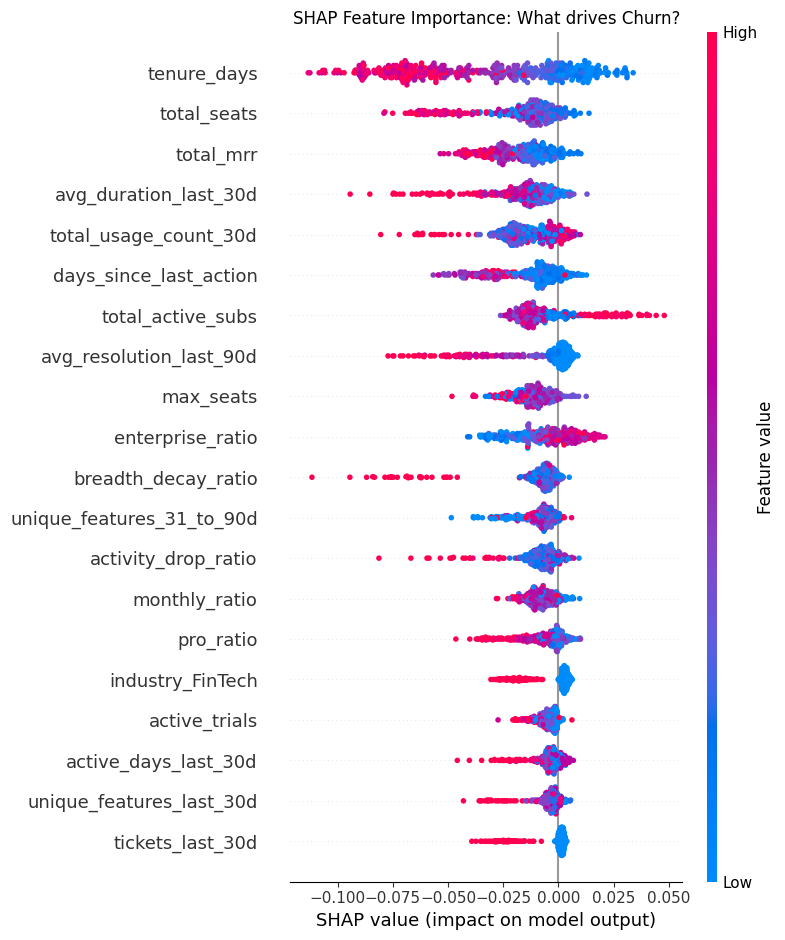

                    Feature  Importance
0               tenure_days    0.038889
3               total_seats    0.019253
2                 total_mrr    0.017845
16    avg_duration_last_30d    0.016395
15    total_usage_count_30d    0.014923
9    days_since_last_action    0.014876
1         total_active_subs    0.013173
22  avg_resolution_last_90d    0.012098
4                 max_seats    0.011888
7          enterprise_ratio    0.011092

🚨 THE TOP 5 DRIVERS OF CHURN 🚨
1. tenure_days
2. total_seats
3. total_mrr
4. avg_duration_last_30d
5. total_usage_count_30d


In [18]:
shap_values_array = np.array(shap_values)

if isinstance(shap_values, list):
    # Older SHAP version (returns list of 2D arrays)
    shap_values_churn = shap_values[1]
elif len(shap_values_array.shape) == 3:
    # Newer SHAP version (returns 3D array: samples, features, classes)
    shap_values_churn = shap_values_array[:, :, 1]
else:
    # Fallback for standard 2D array
    shap_values_churn = shap_values_array

# 5. Plot the Summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_churn, X_eval, show=False)
plt.title("SHAP Feature Importance: What drives Churn?")
plt.tight_layout()
plt.show()

# 6. Extract the exact names of the Top 5 most important features
mean_abs_shap = np.abs(shap_values_churn).mean(axis=0)

shap_df = pd.DataFrame({
    'Feature': X_eval.columns,
    'Importance': mean_abs_shap
})
shap_df = shap_df.sort_values(by='Importance', ascending=False)

print(shap_df.head(10))
print("\n🚨 THE TOP 5 DRIVERS OF CHURN 🚨")
top_5_features = shap_df['Feature'].head(5).tolist()
for i, feature in enumerate(top_5_features, 1):
    print(f"{i}. {feature}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Load model and data
df = X_eval.copy()

# 2. Predict Probabilities
X = df.reindex(columns=expected_features, fill_value=0)
df['Churn_Probability'] = rf_model.predict_proba(X)[:, 1]
print(df['Churn_Probability'].head(20))
# 3. Apply Categories
def assign_tier(p):
    if p >= 0.30: return "High Risk"
    elif p >= 0.20: return "Medium Risk"
    else: return "Low Risk"
df['Risk_Level'] = df['Churn_Probability'].apply(assign_tier)

# 4. Plot the Distribution
plt.figure(figsize=(12, 5))

# Plot A: Customer Count vs Risk Category
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Risk_Level', order=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title("Number of Customers by Risk Category")
plt.ylabel("Customer Count")

# Plot B: Probability Spread by Category
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Risk_Level', y='Churn_Probability', order=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title("Probability Spread per Category")

plt.tight_layout()
plt.show()

# Print the exact counts
print(df['Risk_Level'].value_counts())

In [24]:
df['Churn_Probability'].describe()

count    416.000000
mean       0.242640
std        0.084059
min        0.054720
25%        0.185789
50%        0.236919
75%        0.300256
max        0.511704
Name: Churn_Probability, dtype: float64

In [10]:
df = X_eval.copy()

df['Churn_Probability'] = rf_model.predict_proba(df)[:, 1]
print(df['Churn_Probability'].head(20))

# Calculate the thresholds based on percentiles
medium_threshold = df['Churn_Probability'].quantile(0.75) # Top 25% of users
high_threshold = df['Churn_Probability'].quantile(0.90)   # Top 10% of users

print(f"🚨 To get a realistic dashboard, use these exact thresholds:")
print(f"Set Medium Risk (self.threshold in predictor.py) to: {medium_threshold:.3f}")
print(f"Set High Risk cutoff to: {high_threshold:.3f}")

# Let's preview what the new counts will look like
def new_tier(p):
    if p >= high_threshold: return "High Risk"
    elif p >= medium_threshold: return "Medium Risk"
    else: return "Low Risk"

print("\n📊 New Dashboard Distribution:")
print(df['Churn_Probability'].apply(new_tier).value_counts())

0     0.295902
1     0.202031
2     0.192810
3     0.262963
4     0.075261
5     0.365049
6     0.227622
7     0.282444
8     0.272533
9     0.298492
10    0.288019
11    0.238484
12    0.152538
13    0.196715
14    0.221577
15    0.101223
16    0.297223
17    0.279851
18    0.176946
19    0.244468
Name: Churn_Probability, dtype: float64
🚨 To get a realistic dashboard, use these exact thresholds:
Set Medium Risk (self.threshold in predictor.py) to: 0.300
Set High Risk cutoff to: 0.354

📊 New Dashboard Distribution:
Churn_Probability
Low Risk       312
Medium Risk     62
High Risk       42
Name: count, dtype: int64


## Evidently AI - Drift Detection (Final Chapter)

In [4]:
import pandas as pd
from evidently import Report
from evidently.presets import DataDriftPreset

print("Loading data...")
reference_data = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\processed\not-inference\train_df.csv") 
current_data = pd.read_csv(r"C:\Users\AMAN SINGH\Git\sem6miniProject\customer-churn-prediction\data\processed\inference\september_2024.csv")

print("Building Report Blueprint...")
# 1. We create the blueprint
drift_report = Report(metrics=[DataDriftPreset()])

print("Calculating Statistical Drift...")
# 2. THE FIX: We capture the output of .run() into a new variable called 'my_eval'
my_eval = drift_report.run(reference_data=reference_data, current_data=current_data)

print("Saving HTML...")
# 3. We save the output object, not the blueprint!
my_eval.save_html("my_first_drift_report.html")

print("✅ Report generated successfully! Open 'my_first_drift_report.html' in your browser.")

Loading data...
Building Report Blueprint...
Calculating Statistical Drift...


c:\Users\AMAN SINGH\Git\sem6miniProject\Customer-Churn-Prediction\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

c:\Users\AMAN SINGH\Git\sem6miniProject\Customer-Churn-Prediction\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

c:\Users\AMAN SINGH\Git\sem6miniProject\Customer-Churn-Prediction\venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.



Saving HTML...
✅ Report generated successfully! Open 'my_first_drift_report.html' in your browser.


In [7]:
results = my_eval.dict()
results.keys()

dict_keys(['metrics', 'tests'])

In [13]:
results['metrics']


[{'id': '15e89f895b482f9b84ba7274ed18a106',
  'metric_name': 'DriftedColumnsCount(drift_share=0.5)',
  'config': {'type': 'evidently:metric_v2:DriftedColumnsCount',
   'drift_share': 0.5},
  'value': {'count': 17.0, 'share': 0.4722222222222222}},
 {'id': '65b565177467df71f170124d6772d81d',
  'metric_name': 'ValueDrift(column=tenure_days,method=Wasserstein distance (normed),threshold=0.1)',
  'config': {'type': 'evidently:metric_v2:ValueDrift',
   'column': 'tenure_days',
   'method': 'Wasserstein distance (normed)',
   'threshold': 0.1},
  'value': np.float64(0.6636773637618172)},
 {'id': '49c86d96f230f057f64483f0a644a444',
  'metric_name': 'ValueDrift(column=total_active_subs,method=Wasserstein distance (normed),threshold=0.1)',
  'config': {'type': 'evidently:metric_v2:ValueDrift',
   'column': 'total_active_subs',
   'method': 'Wasserstein distance (normed)',
   'threshold': 0.1},
  'value': np.float64(0.9606189602536377)},
 {'id': 'b9a78f3ba191d5035d2aff538576a73d',
  'metric_name'

In [15]:
raw_results = my_eval.dict()

# 1. Get the summary from the very first metric (DriftedColumnsCount)
summary_metric = raw_results["metrics"][0]
drifted_features = int(summary_metric["value"]["count"])
total_features = int(drifted_features / summary_metric["value"]["share"])

print(f"🚨 ALERT: {drifted_features} out of {total_features} features have drifted!\n")

# 2. Loop through the rest of the list to find EXACTLY which columns are drifting
drifted_details = []

# We skip the first item [1:] because it's just the summary count
for m in raw_results["metrics"][1:]: 
    col_name = m["config"]["column"]
    score = float(m["value"])
    threshold = float(m["config"]["threshold"])
    
    # In Evidently, if the distance score is higher than the threshold, it means it drifted
    if score > threshold:
        drifted_details.append({"Feature": col_name, "Drift Score": score, "Threshold": threshold})

# 3. Sort them to find the worst offenders
import pandas as pd
drift_df = pd.DataFrame(drifted_details).sort_values(by="Drift Score", ascending=False)

print("🔍 Top 5 Most Drifting Features:")
print(drift_df.head(5).to_string(index=False))

🚨 ALERT: 17 out of 36 features have drifted!

🔍 Top 5 Most Drifting Features:
          Feature  Drift Score  Threshold
total_active_subs     0.960619        0.1
    snapshot_date     0.832555        0.1
      total_seats     0.784806        0.1
      tenure_days     0.663677        0.1
        total_mrr     0.655463        0.1
